# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [2]:
df = pd.read_csv("data/aviation_accidents_cleaned.csv", low_memory=False)
print(df.shape)
print(df.head().to_string())
print(df.dtypes)


(17892, 38)
         Event.Id Investigation.Type Accident.Number  Event.Date               Location        Country Latitude Longitude Airport.Code      Airport.Name Injury.Severity Aircraft.damage Aircraft.Category Registration.Number          Make      Model Amateur.Built  Number.of.Engines    Engine.Type            FAR.Description Purpose.of.flight  Total.Fatal.Injuries  Total.Serious.Injuries  Total.Minor.Injuries  Total.Uninjured Weather.Condition Broad.phase.of.flight   Report.Status Publication.Date  Total.Passengers.Est  Serious.Fatal.Fraction  Fatal.Fraction Aircraft.Damage.Clean  Destroyed.Flag    Make.Clean Model.Clean          Plane.Type  Number.of.Engines.Clean
0  20001214X42478           Incident     LAX83IA149A  1983-03-18        LOS ANGELES, CA  United States      NaN       NaN          LAX  LOS ANGELES INTL        Incident           Minor          Airplane               9VSQQ        Boeing        747            No                4.0      Turbo Fan          Part 129: For

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [3]:
df = df.copy()
df["Passenger.Capacity"] = pd.to_numeric(df.get("Total.Passengers.Est", pd.Series(np.nan)), errors="coerce")
df["Passenger.Capacity"] = df["Passenger.Capacity"].fillna(df["Passenger.Capacity"].median())
df["Small.Aircraft"] = df["Passenger.Capacity"] <= 20
print(df[["Passenger.Capacity", "Small.Aircraft"]].head())

   Passenger.Capacity  Small.Aircraft
0               588.0           False
1                 2.0            True
2                 5.0            True
3               100.0           False
4                 1.0            True


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

C:\Users\User\AppData\Local\Temp\ipykernel_22820\3220121967.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  small_make_stats = small.groupby("Make.Clean").apply(lambda g: pd.Series({
C:\Users\User\AppData\Local\Temp\ipykernel_22820\3220121967.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  large_make_stats = large.groupby("Make.Clean").apply(lambda g: pd.Series({


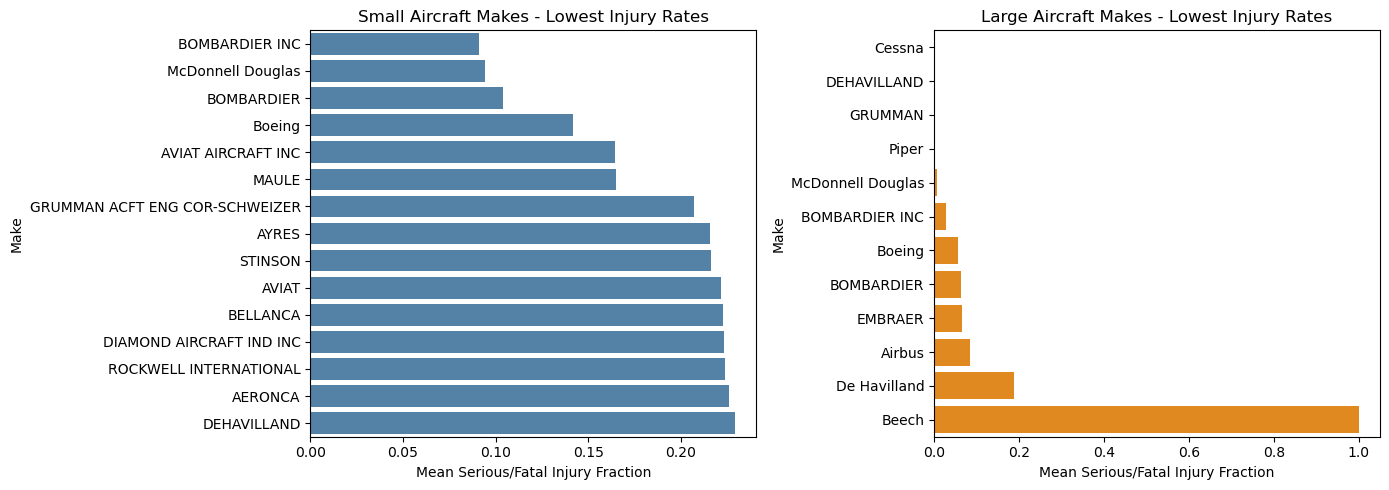

                    Make.Clean  mean_injury_rate  count
                BOMBARDIER INC          0.090909   22.0
             McDonnell Douglas          0.094048   55.0
                    BOMBARDIER          0.103846   29.0
                        Boeing          0.141453  720.0
            AVIAT AIRCRAFT INC          0.164474   76.0
                         MAULE          0.164806  215.0
GRUMMAN ACFT ENG COR-SCHWEIZER          0.206897   58.0
                         AYRES          0.215686   52.0
                       STINSON          0.216408  129.0
                         AVIAT          0.221429   70.0
                      BELLANCA          0.222603  219.0
      DIAMOND AIRCRAFT IND INC          0.222973   74.0
        ROCKWELL INTERNATIONAL          0.223684   58.0
                       AERONCA          0.225833  200.0
                   DEHAVILLAND          0.229188   94.0

       Make.Clean  mean_injury_rate  count
           Cessna          0.000000    2.0
      DEHAVILLAND

In [4]:
small = df[df["Small.Aircraft"]].copy()
large = df[~df["Small.Aircraft"]].copy()

small_make_stats = small.groupby("Make.Clean").apply(lambda g: pd.Series({
    "mean_injury_rate": g["Serious.Fatal.Fraction"].mean(),
    "count": g.shape[0],
})).reset_index().sort_values("mean_injury_rate")
large_make_stats = large.groupby("Make.Clean").apply(lambda g: pd.Series({
    "mean_injury_rate": g["Serious.Fatal.Fraction"].mean(),
    "count": g.shape[0],
})).reset_index().sort_values("mean_injury_rate")

small_top = small_make_stats.head(15)
large_top = large_make_stats.head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=small_top, x="mean_injury_rate", y="Make.Clean", ax=axes[0], color="steelblue")
axes[0].set_title("Small Aircraft Makes - Lowest Injury Rates")
axes[0].set_xlabel("Mean Serious/Fatal Injury Fraction")
axes[0].set_ylabel("Make")

sns.barplot(data=large_top, x="mean_injury_rate", y="Make.Clean", ax=axes[1], color="darkorange")
axes[1].set_title("Large Aircraft Makes - Lowest Injury Rates")
axes[1].set_xlabel("Mean Serious/Fatal Injury Fraction")
axes[1].set_ylabel("Make")
plt.tight_layout()
plt.show()

print(small_top.to_string(index=False))
print('\n' + large_top.to_string(index=False))

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

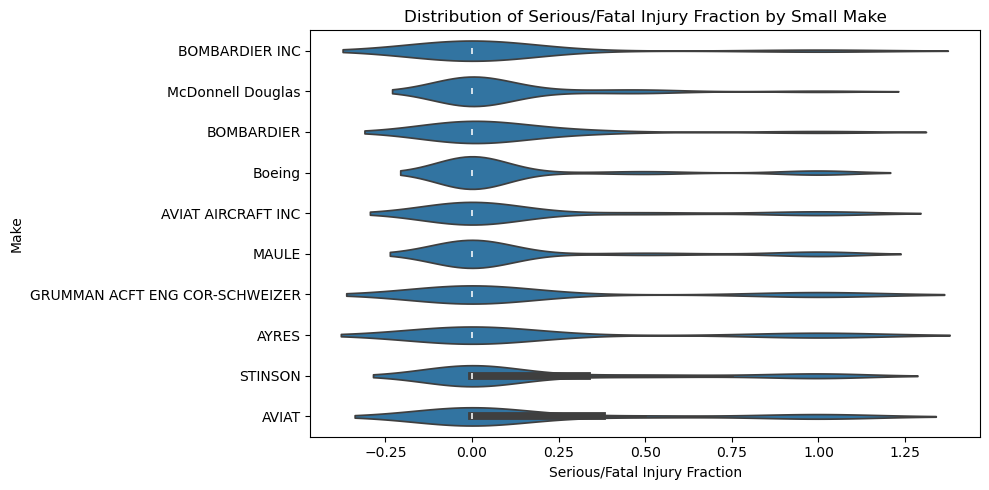

In [5]:
small_top_10 = small_make_stats.head(10)
plt.figure(figsize=(10, 5))
sns.violinplot(data=small[small["Make.Clean"].isin(small_top_10["Make.Clean"])], x="Serious.Fatal.Fraction", y="Make.Clean", order=small_top_10["Make.Clean"], orient="h")
plt.title("Distribution of Serious/Fatal Injury Fraction by Small Make")
plt.xlabel("Serious/Fatal Injury Fraction")
plt.ylabel("Make")
plt.tight_layout()
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

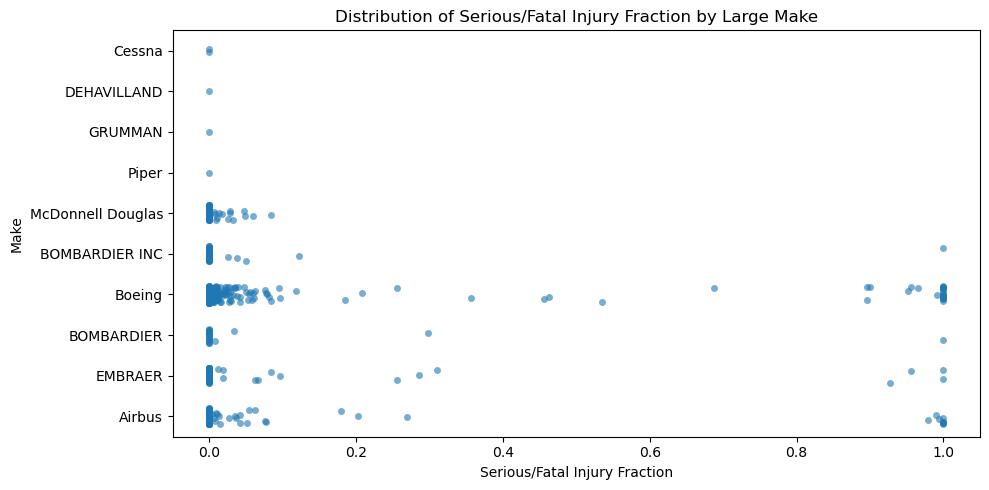

In [6]:
large_top_10 = large_make_stats.head(10)
plt.figure(figsize=(10, 5))
sns.stripplot(data=large[large["Make.Clean"].isin(large_top_10["Make.Clean"])], x="Serious.Fatal.Fraction", y="Make.Clean", order=large_top_10["Make.Clean"], orient="h", jitter=0.2, alpha=0.6)
plt.title("Distribution of Serious/Fatal Injury Fraction by Large Make")
plt.xlabel("Serious/Fatal Injury Fraction")
plt.ylabel("Make")
plt.tight_layout()
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [7]:
destroyed_summary = df.groupby(["Small.Aircraft", "Make.Clean"]).agg(
    destroyed_fraction=("Destroyed.Flag", "mean"),
    n=("Destroyed.Flag", "size"),
).reset_index()

small_destroyed = destroyed_summary[destroyed_summary["Small.Aircraft"]].sort_values("destroyed_fraction").head(15)
large_destroyed = destroyed_summary[~destroyed_summary["Small.Aircraft"]].sort_values("destroyed_fraction").head(15)

print(small_destroyed.to_string(index=False))
print('\n' + large_destroyed.to_string(index=False))

 Small.Aircraft                     Make.Clean  destroyed_fraction   n
           True                       LUSCOMBE            0.014184 141
           True GRUMMAN ACFT ENG COR-SCHWEIZER            0.017241  58
           True                        STINSON            0.023256 129
           True                         Airbus            0.024000 125
           True                    TAYLORCRAFT            0.032258  93
           True                     BOMBARDIER            0.034483  29
           True                        AERONCA            0.035000 200
           True                         Boeing            0.036111 720
           True     AMERICAN CHAMPION AIRCRAFT            0.038462  52
           True                        ERCOUPE            0.038462  52
           True             AVIAT AIRCRAFT INC            0.039474  76
           True                          MAULE            0.041860 215
           True                    DEHAVILLAND            0.042553  94
      

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

In [8]:
print("Small aircraft makes with the lowest injury rates:")
print(small_top.head(10).to_string(index=False))
print("\nLarge aircraft makes with the lowest injury rates:")
print(large_top.head(10).to_string(index=False))
print("\nSmall aircraft makes with the lowest destruction rates:")
print(small_destroyed.head(10).to_string(index=False))
print("\nLarge aircraft makes with the lowest destruction rates:")
print(large_destroyed.head(10).to_string(index=False))

Small aircraft makes with the lowest injury rates:
                    Make.Clean  mean_injury_rate  count
                BOMBARDIER INC          0.090909   22.0
             McDonnell Douglas          0.094048   55.0
                    BOMBARDIER          0.103846   29.0
                        Boeing          0.141453  720.0
            AVIAT AIRCRAFT INC          0.164474   76.0
                         MAULE          0.164806  215.0
GRUMMAN ACFT ENG COR-SCHWEIZER          0.206897   58.0
                         AYRES          0.215686   52.0
                       STINSON          0.216408  129.0
                         AVIAT          0.221429   70.0

Large aircraft makes with the lowest injury rates:
       Make.Clean  mean_injury_rate  count
           Cessna          0.000000    2.0
      DEHAVILLAND          0.000000    1.0
          GRUMMAN          0.000000    1.0
            Piper          0.000000    1.0
McDonnell Douglas          0.007827   53.0
   BOMBARDIER INC      

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

                Plane.Type  Small.Aircraft  mean_injury_rate  count  destroyed_fraction
                Boeing 777           False          0.000821     33            0.030303
                Boeing 757           False          0.001473     18            0.000000
                Boeing 787           False          0.003058     11            0.000000
            Boeing 737-7H4           False          0.003242     12            0.000000
BOMBARDIER INC CL-600-2B19           False          0.004431     14            0.000000
            EMBRAER EMB145           False          0.008798     11            0.000000
         EMBRAER EMB-145LR           False          0.010000     15            0.000000
                Boeing 747           False          0.023161     11            0.000000
                Boeing 767           False          0.046963     31            0.032258
            Boeing 737 7H4           False          0.068121     14            0.000000
                Boeing 737      

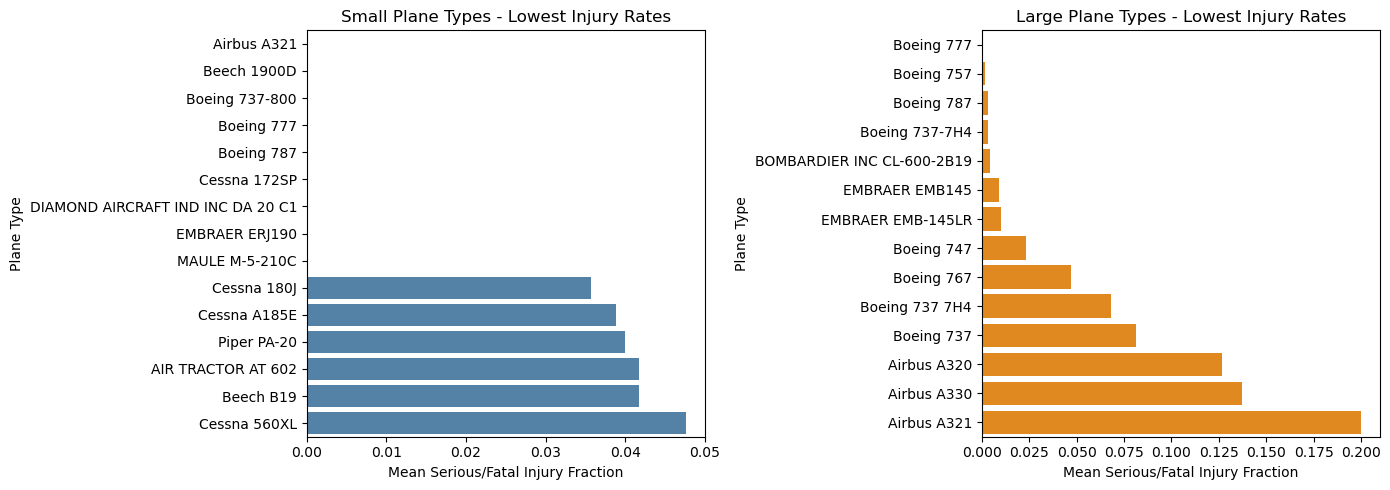

In [9]:
plane_stats = df.groupby(["Plane.Type", "Small.Aircraft"]).agg(
    mean_injury_rate=("Serious.Fatal.Fraction", "mean"),
    count=("Serious.Fatal.Fraction", "size"),
    destroyed_fraction=("Destroyed.Flag", "mean"),
).reset_index()
plane_stats = plane_stats[plane_stats["count"] >= 10].sort_values(["Small.Aircraft", "mean_injury_rate"])
print(plane_stats.head(20).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
small_plane = plane_stats[plane_stats["Small.Aircraft"]].head(15)
large_plane = plane_stats[~plane_stats["Small.Aircraft"]].head(15)
sns.barplot(data=small_plane, x="mean_injury_rate", y="Plane.Type", ax=axes[0], color="steelblue")
axes[0].set_title("Small Plane Types - Lowest Injury Rates")
axes[0].set_xlabel("Mean Serious/Fatal Injury Fraction")
axes[0].set_ylabel("Plane Type")

sns.barplot(data=large_plane, x="mean_injury_rate", y="Plane.Type", ax=axes[1], color="darkorange")
axes[1].set_title("Large Plane Types - Lowest Injury Rates")
axes[1].set_xlabel("Mean Serious/Fatal Injury Fraction")
axes[1].set_ylabel("Plane Type")
plt.tight_layout()
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

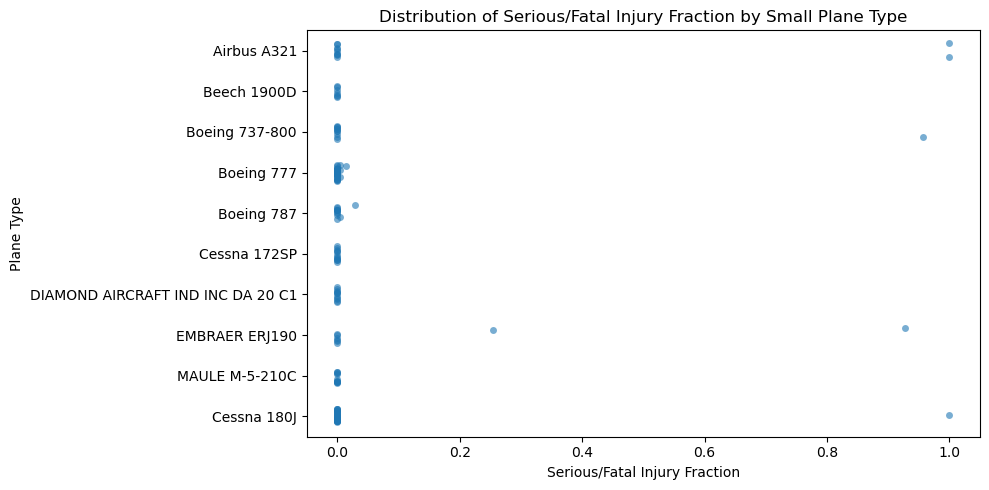

In [10]:
small_plane_plot = plane_stats[plane_stats["Small.Aircraft"]].head(10)
plt.figure(figsize=(10, 5))
sns.stripplot(data=df[df["Plane.Type"].isin(small_plane_plot["Plane.Type"])], x="Serious.Fatal.Fraction", y="Plane.Type", order=small_plane_plot["Plane.Type"], orient="h", jitter=0.2, alpha=0.6)
plt.title("Distribution of Serious/Fatal Injury Fraction by Small Plane Type")
plt.xlabel("Serious/Fatal Injury Fraction")
plt.ylabel("Plane Type")
plt.tight_layout()
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

In [11]:
print("Lowest-injury plane types with at least 10 observations:")
print(plane_stats.head(20).to_string(index=False))

Lowest-injury plane types with at least 10 observations:
                Plane.Type  Small.Aircraft  mean_injury_rate  count  destroyed_fraction
                Boeing 777           False          0.000821     33            0.030303
                Boeing 757           False          0.001473     18            0.000000
                Boeing 787           False          0.003058     11            0.000000
            Boeing 737-7H4           False          0.003242     12            0.000000
BOMBARDIER INC CL-600-2B19           False          0.004431     14            0.000000
            EMBRAER EMB145           False          0.008798     11            0.000000
         EMBRAER EMB-145LR           False          0.010000     15            0.000000
                Boeing 747           False          0.023161     11            0.000000
                Boeing 767           False          0.046963     31            0.032258
            Boeing 737 7H4           False          0.068121   

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

Weather.Condition  injury_rate  destroyed_fraction     n
              VMC     0.233153            0.070989 14298
          Unknown     0.420061            0.185709  2687
              IMC     0.627723            0.348401   907


C:\Users\User\AppData\Local\Temp\ipykernel_22820\3015965588.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weather, x="Weather.Condition", y="injury_rate", palette="viridis")


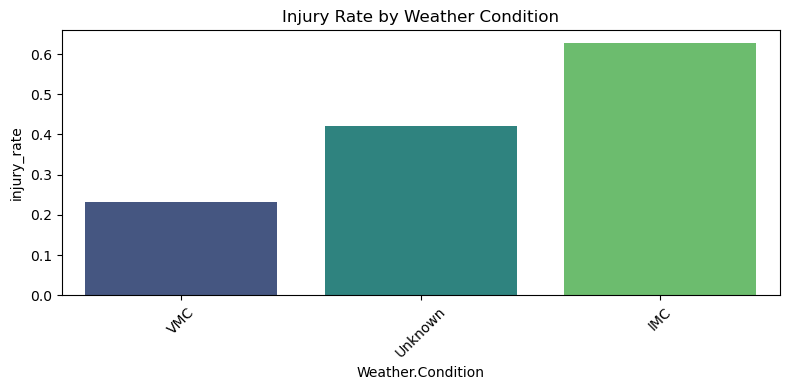

In [12]:
weather = df.groupby("Weather.Condition").agg(
    injury_rate=("Serious.Fatal.Fraction", "mean"),
    destroyed_fraction=("Destroyed.Flag", "mean"),
    n=("Destroyed.Flag", "size"),
).reset_index().sort_values("injury_rate")
print(weather.to_string(index=False))

plt.figure(figsize=(8, 4))
sns.barplot(data=weather, x="Weather.Condition", y="injury_rate", palette="viridis")
plt.title("Injury Rate by Weather Condition")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

    Engine.Type  injury_rate  destroyed_fraction     n
Geared Turbofan     0.000000            0.000000    12
      Turbo Fan     0.089659            0.049787   703
    Turbo Shaft     0.111111            0.000000     9
      Turbo Jet     0.195023            0.154930    71
  Reciprocating     0.254186            0.078367 12837
     Turbo Prop     0.320931            0.182599   931
        Unknown     0.402644            0.182637  3329


C:\Users\User\AppData\Local\Temp\ipykernel_22820\3448374353.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=engine, x="Engine.Type", y="injury_rate", palette="mako")


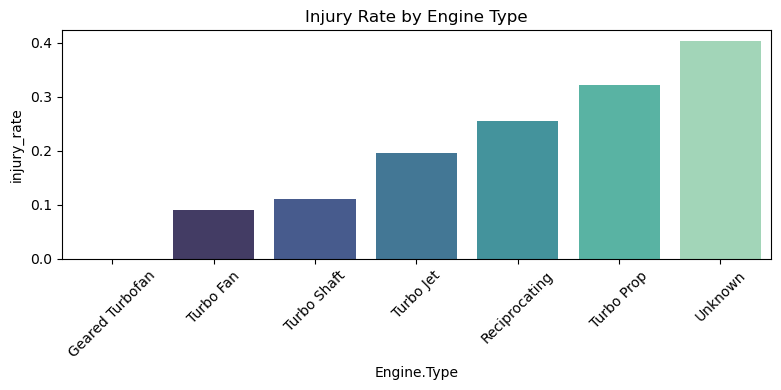

In [13]:
engine = df.groupby("Engine.Type").agg(
    injury_rate=("Serious.Fatal.Fraction", "mean"),
    destroyed_fraction=("Destroyed.Flag", "mean"),
    n=("Destroyed.Flag", "size"),
).reset_index().sort_values("injury_rate")
print(engine.to_string(index=False))

plt.figure(figsize=(8, 4))
sns.barplot(data=engine, x="Engine.Type", y="injury_rate", palette="mako")
plt.title("Injury Rate by Engine Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()